# Lección 4: Paradigmas de IA

**Módulo 1:** Introducción a la Inteligencia Artificial

**Objetivos de la Lección:**
- Comparar Sistemas Expertos, Basados en Reglas, ML, Deep Learning y LLMs
- Implementar un sistema basado en reglas y un modelo básico de ML
- Elegir el paradigma apropiado para un problema dado

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris, load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

print("Libraries loaded successfully")

Libraries loaded successfully


## Paradigma 1: Sistema Basado en Reglas

Construyamos un verificador de síntomas médico usando reglas explícitas.

In [2]:
def symptom_checker(symptoms):
    """Rule-based medical symptom checker."""
    symptom_set = set(s.lower() for s in symptoms)
    
    # Define rules
    if {"fever", "cough", "shortness_of_breath"}.issubset(symptom_set):
        return "Possible pneumonia — seek medical attention"
    if {"fever", "headache", "stiff_neck"}.issubset(symptom_set):
        return "Possible meningitis — URGENT"
    if {"fever", "rash", "joint_pain"}.issubset(symptom_set):
        return "Possible dengue fever"
    if {"fatigue", "weight_loss", "night_sweats"}.issubset(symptom_set):
        return "Possible tuberculosis"
    if {"sneezing", "runny_nose", "watery_eyes"}.issubset(symptom_set):
        return "Possible allergies"
    if {"fever", "cough", "fatigue"}.issubset(symptom_set):
        return "Possible common cold or flu"
    
    return "No matching condition found — consult a doctor"


# Test the rule-based system
test_cases = [
    ["fever", "cough", "shortness_of_breath"],
    ["fatigue", "weight_loss", "night_sweats"],
    ["fever", "headache"],  # Not enough symptoms
    ["sneezing", "runny_nose", "watery_eyes"],
]

print("Rule-Based Symptom Checker Results:")
print("-" * 50)
for case in test_cases:
    result = symptom_checker(case)
    print(f"Symptoms: {case}")
    print(f"  → {result}\n")

Rule-Based Symptom Checker Results:
--------------------------------------------------
Symptoms: ['fever', 'cough', 'shortness_of_breath']
  → Possible pneumonia — seek medical attention

Symptoms: ['fatigue', 'weight_loss', 'night_sweats']
  → Possible tuberculosis

Symptoms: ['fever', 'headache']
  → No matching condition found — consult a doctor

Symptoms: ['sneezing', 'runny_nose', 'watery_eyes']
  → Possible allergies



### Limitación: Fragilidad

Observa que "fiebre + dolor de cabeza" no devuelve ninguna coincidencia. Si agregamos "fiebre" y "tos" sin "fatiga", la regla del resfriado común no se activa. Esta es la **fragilidad** de los sistemas basados en reglas — solo coinciden con patrones exactos.

## Paradigma 2: Machine Learning (Árbol de Decisión)

Ahora entrenemos un modelo de Machine Learning que aprende reglas a partir de datos en lugar de requerir reglas hechas a mano.

In [3]:
# Load the iris dataset
iris = load_iris()
X, y = iris.data, iris.target
feature_names = iris.feature_names
target_names = iris.target_names

print(f"Dataset: {X.shape[0]} samples, {X.shape[1]} features")
print(f"Feature names: {feature_names}")
print(f"Target names: {target_names}")
print(f"\nFirst 5 rows:")
print(pd.DataFrame(X, columns=feature_names).head())

Dataset: 150 samples, 4 features
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [4]:
# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

Training samples: 105
Test samples: 45


In [5]:
# Train a Decision Tree classifier
dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_model.fit(X_train, y_train)

# Predict on test set
y_pred = dt_model.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
print(f"Decision Tree Accuracy: {accuracy:.2%}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(pd.DataFrame(cm, index=target_names, columns=target_names))

Decision Tree Accuracy: 97.78%

Confusion Matrix:
            setosa  versicolor  virginica
setosa          15           0          0
versicolor       0          14          1
virginica        0           0         15


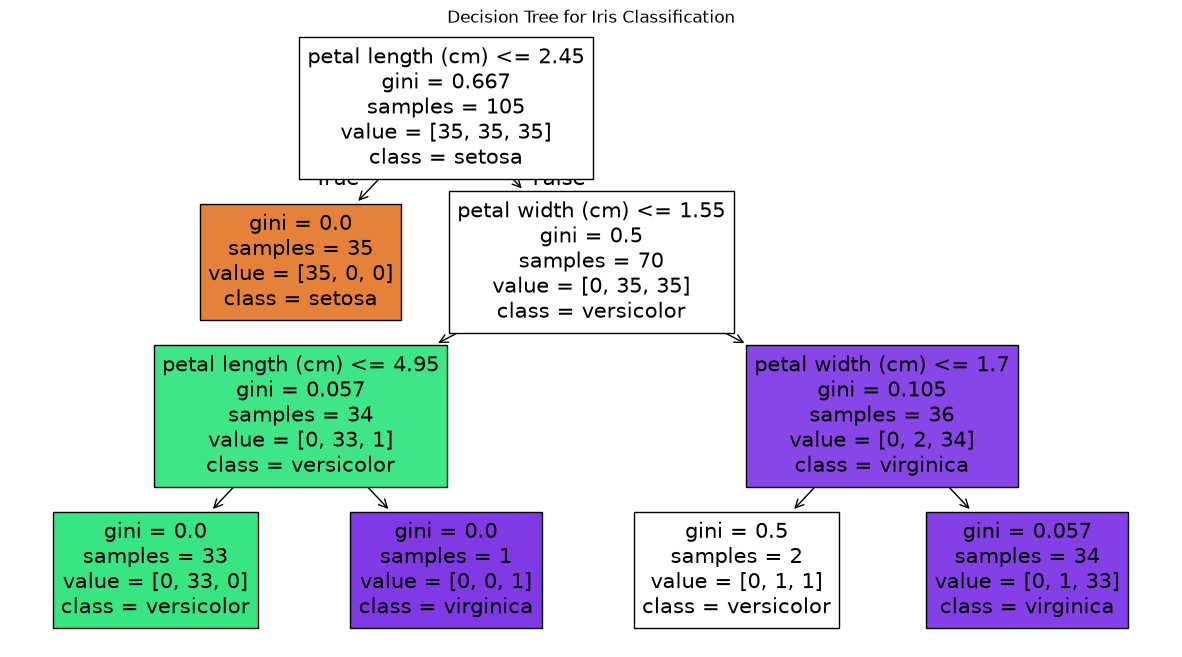

In [6]:
# Visualize the decision tree
plt.figure(figsize=(15, 8))
plot_tree(dt_model, feature_names=feature_names, 
          class_names=target_names.tolist(), filled=True)
plt.title("Decision Tree for Iris Classification")
plt.show()

### Interpretando el Árbol de Decisión

El Árbol de Decisión aprendió reglas automáticamente a partir de los datos:
- **Primera división**: longitud del pétalo (<= 2.45 cm) → setosa vs. versicolor/virginica
- **Segunda división**: ancho y longitud del pétalo separan aún más versicolor de virginica

Estas reglas son similares a lo que un experto podría escribir, pero fueron *aprendidas de datos* en lugar de hechas a mano.

## Paradigma 3: Concepto de Red Neuronal Simple

Demostremos una neurona individual (perceptrón) — el bloque de construcción del deep learning.

In [7]:
class Neuron:
    """A single artificial neuron."""
    
    def __init__(self, n_inputs):
        self.weights = np.random.randn(n_inputs) * 0.1
        self.bias = np.random.randn() * 0.1
    
    def sigmoid(self, x):
        return 1 / (1 + np.exp(-np.clip(x, -500, 500)))
    
    def forward(self, inputs):
        """Forward pass: compute output."""
        z = np.dot(inputs, self.weights) + self.bias
        return self.sigmoid(z)
    
    def __repr__(self):
        return f"Neuron(weights={self.weights.round(3)}, bias={self.bias:.3f})"


# Create a neuron and test it
n = Neuron(4)  # 4 inputs (like iris features)
sample = X_test[0]
output = n.forward(sample)

print(f"Input: {sample}")
print(f"Output: {output:.4f}")
print(f"Interpretation: Probability of class 1 = {output:.2%}")

Input: [7.3 2.9 6.3 1.8]
Output: 0.7473
Interpretation: Probability of class 1 = 74.73%


## Sistema Híbrido: Reglas + ML

En producción, los sistemas a menudo combinan múltiples paradigmas. Aquí hay un enfoque híbrido.

In [8]:
def hybrid_predict(sepal_length, sepal_width, petal_length, petal_width):
    """
    Hybrid iris classifier.
    Rule-based for clear cases, ML for uncertain ones.
    """
    # Rule: very small petals = setosa
    if petal_length < 2.0:
        return ("setosa", "rule-based")
    
    # Rule: very large petals = virginica
    if petal_length > 5.5:
        return ("virginica", "rule-based")
    
    # Otherwise, use the ML model
    features = np.array([[sepal_length, sepal_width, petal_length, petal_width]])
    pred = dt_model.predict(features)[0]
    return (target_names[pred], "ml")


# Test the hybrid system
test_samples = [
    (5.1, 3.5, 1.4, 0.2),  # Small petals → setosa (rule)
    (6.5, 3.0, 5.2, 2.0),  # Large petals → virginica (rule)
    (6.0, 2.7, 4.5, 1.5),  # Medium → ML
]

print("Hybrid Classifier Results:")
print("-" * 40)
for sample in test_samples:
    result, method = hybrid_predict(*sample)
    print(f"Input: {sample} → {result} (via {method})")

Hybrid Classifier Results:
----------------------------------------
Input: (5.1, 3.5, 1.4, 0.2) → setosa (via rule-based)
Input: (6.5, 3.0, 5.2, 2.0) → virginica (via ml)
Input: (6.0, 2.7, 4.5, 1.5) → versicolor (via ml)


## Ejemplo en Biotecnología: Predicción de Función de Proteínas

Compara paradigmas para predecir la función de proteínas a partir de la secuencia.

In [9]:
# Simulated protein sequences and functions
proteins = [
    {"sequence": "MVLSPADKTNVKAAW", "motif": "heme_binding", "function": "Hemoglobin"},
    {"sequence": "MGHFTEEDKATITSL", "motif": "atp_binding", "function": "Kinase"},
    {"sequence": "MAKEGVKAVKAVLV", "motif": "dna_binding", "function": "Transcription factor"},
]

def rule_based_function(sequence):
    """Predict protein function using motifs."""
    if "heme" in sequence.lower():
        return "Hemoglobin (heme-binding protein)"
    if "atp" in sequence.lower():
        return "Kinase (ATP-binding protein)"
    if "dna" in sequence.lower():
        return "Transcription factor (DNA-binding protein)"
    return "Unknown function"


print("Rule-Based Protein Function Prediction:")
for p in proteins:
    pred = rule_based_function(p["sequence"])
    print(f"  {p['sequence']} → {pred}")

Rule-Based Protein Function Prediction:
  MVLSPADKTNVKAAW → Unknown function
  MGHFTEEDKATITSL → Unknown function
  MAKEGVKAVKAVLV → Unknown function


## Ejemplo en SaaS: Abandono de Clientes

Compara enfoques basados en reglas y de ML para la predicción de abandono.

In [10]:
# Generate synthetic customer data
np.random.seed(42)
n_customers = 200

customers = pd.DataFrame({
    'login_frequency': np.random.randint(0, 30, n_customers),
    'support_tickets': np.random.randint(0, 10, n_customers),
    'days_since_last_purchase': np.random.randint(0, 365, n_customers),
    'satisfaction_score': np.random.uniform(1, 5, n_customers),
})

def rule_based_churn(customer):
    """Rule-based churn prediction."""
    score = 0
    if customer['login_frequency'] < 5: score += 1
    if customer['support_tickets'] > 5: score += 1
    if customer['days_since_last_purchase'] > 180: score += 1
    if customer['satisfaction_score'] < 2.5: score += 1
    return score >= 2


# Apply rules
customers['churn_risk_rule'] = customers.apply(rule_based_churn, axis=1)

print("Rule-Based Churn Prediction (First 10 customers):")
print(customers.head(10))
print(f"\nCustomers at risk (rule): {customers['churn_risk_rule'].sum()} / {n_customers}")

Rule-Based Churn Prediction (First 10 customers):
   login_frequency  support_tickets  days_since_last_purchase  \
0                6                6                       298   
1               19                3                       245   
2               28                6                       175   
3               14                2                        38   
4               10                5                       169   
5                7                1                       246   
6               28                9                        25   
7               20                8                       354   
8                6                4                       305   
9               25                5                        12   

   satisfaction_score  churn_risk_rule  
0            1.043351             True  
1            4.621528            False  
2            1.365147             True  
3            2.277255            False  
4            4.800248        

## Ejercicios

1. Agrega 3 reglas más al verificador de síntomas y pruébalas.
2. Entrena un clasificador Random Forest en el conjunto de datos de vino y compara su precisión con el Árbol de Decisión.
3. Diseña un sistema híbrido para un problema de tu elección — describe los componentes de reglas y ML.

In [11]:
# Exercise 2: Random Forest on wine dataset
from sklearn.ensemble import RandomForestClassifier

wine = load_wine()
X_w, y_w = wine.data, wine.target

Xw_train, Xw_test, yw_train, yw_test = train_test_split(
    X_w, y_w, test_size=0.3, random_state=42
)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(Xw_train, yw_train)
rf_pred = rf.predict(Xw_test)
rf_accuracy = accuracy_score(yw_test, rf_pred)

print(f"Random Forest Accuracy on Wine: {rf_accuracy:.2%}")

Random Forest Accuracy on Wine: 100.00%


## Resumen

- Cinco paradigmas de IA: Sistemas Expertos, Basados en Reglas, ML, Deep Learning, LLMs
- Basado en Reglas: interpretable, sin datos, pero frágil
- ML: aprende de datos, generaliza, necesita ejemplos
- Deep Learning: maneja patrones complejos, necesita escala
- LLMs: comprensión del lenguaje, habilidades emergentes
- Los sistemas híbridos combinan lo mejor de múltiples paradigmas